<a href="https://colab.research.google.com/github/vifirsanova/ML-2026-pt-2/blob/main/5_low_level_tools/native_rag_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Низкоуровневый пример построения RAG-системы на основе инструментов традиционного ML

### 1. Импорты

In [16]:
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
from collections import deque
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from typing import List, Dict, Tuple, Set, Any
import nltk
from nltk.tokenize import sent_tokenize
import networkx as nx
from dataclasses import dataclass
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### 2. Скрейпинг

In [3]:
class NativeScraper:
    """Pure Python web scraper using requests + BeautifulSoup"""

    def __init__(self, base_url: str):
        self.base_url = base_url
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (compatible; RAGBot/1.0)'
        })

    def scrape_page(self, url: str) -> Dict[str, Any]:
        """Scrape a single page with full control"""
        response = self.session.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Extract metadata
        title = soup.title.string if soup.title else ""

        # Remove script and style elements
        for script in soup(["script", "style", "nav", "footer", "header"]):
            script.decompose()

        # Get text with paragraph preservation
        paragraphs = []
        for p in soup.find_all(['p', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'li']):
            text = p.get_text(strip=True)
            if text and len(text) > 20:
                paragraphs.append(text)

        # Extract links for crawling
        links = []
        for a in soup.find_all('a', href=True):
            href = a['href']
            if href.startswith('/') or self.base_url in href:
                full_url = href if href.startswith('http') else self.base_url + href
                links.append(full_url)

        return {
            'url': url,
            'title': title,
            'paragraphs': paragraphs,
            'raw_text': '\n'.join(paragraphs),
            'links': links[:10],  # Limit for demo
            'word_count': len(soup.get_text().split())
        }

    def crawl_site(self, start_url: str, max_pages: int = 3,
                   same_domain: bool = True) -> List[Dict[str, Any]]:
        """Crawl multiple pages with BFS-like approach"""
        visited = set()
        queue = deque([start_url])
        results = []

        while queue and len(results) < max_pages:
            url = queue.popleft()
            if url in visited:
                continue

            visited.add(url)
            try:
                page_data = self.scrape_page(url)
                results.append(page_data)

                # Add new links to queue
                for link in page_data['links']:
                    if link not in visited and len(results) < max_pages:
                        if same_domain and self.base_url in link:
                            queue.append(link)
                        elif not same_domain:
                            queue.append(link)

            except Exception as e:
                print(f"Error scraping {url}: {e}")

        return results

In [4]:
# Demo with a real website (Wikipedia article for reliability)
scraper = NativeScraper("https://en.wikipedia.org")
wiki_articles = scraper.crawl_site(
    "https://en.wikipedia.org/wiki/Natural_language_processing",
    max_pages=2
)

In [7]:
print(f"Scraped {len(wiki_articles)} pages")
for page in wiki_articles:
    print(f"  - {page['title']}: {page['word_count']} words")

Scraped 2 pages
  - Natural language processing - Wikipedia: 7101 words
  - View source for Natural language processing - Wikipedia: 7950 words


In [10]:
!pip install langchain langchain-community -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [12]:
# LangChain comparison
def langchain_scraper_example(url: str):
    """
    Equivalent LangChain scraper for comparison.
    Shows how LangChain abstracts away the scraping process.
    """
    from langchain_community.document_loaders import WebBaseLoader

    loader = WebBaseLoader(url)
    documents = loader.load()

    # LangChain automatically:
    # 1. Handles HTTP requests
    # 2. Parses HTML
    # 3. Extracts text
    # 4. Creates Document objects with metadata

    return documents

documents = langchain_scraper_example('https://en.wikipedia.org/wiki/Natural_language_processing')

/tmp/ipykernel_517/787763585.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


### 3. Чанкинг

In [14]:
class NativeChunker:
    """Manual text chunking with multiple strategies"""

    @staticmethod
    def sentence_chunk(text: str, max_sentences: int = 5,
                       overlap: int = 1) -> List[Dict[str, Any]]:
        """Chunk by sentences with configurable overlap"""
        sentences = sent_tokenize(text)
        chunks = []

        i = 0
        while i < len(sentences):
            chunk_sentences = sentences[i:i + max_sentences]
            chunk_text = ' '.join(chunk_sentences)

            chunks.append({
                'text': chunk_text,
                'start_idx': i,
                'end_idx': i + len(chunk_sentences),
                'chunk_size': len(chunk_sentences)
            })

            # Move with overlap
            i += max_sentences - overlap

        return chunks

    @staticmethod
    def sliding_window(text: str, window_size: int = 100,
                       overlap: int = 20) -> List[str]:
        """Sliding window with character-level overlap"""
        words = text.split()
        chunks = []

        for i in range(0, len(words), window_size - overlap):
            chunk = ' '.join(words[i:i + window_size])
            if chunk:
                chunks.append(chunk)

        return chunks

    @staticmethod
    def semantic_chunk(text: str, separator: str = '\n\n') -> List[str]:
        """Chunk by semantic boundaries (paragraphs, sections)"""
        # Remove empty chunks and whitespace-only chunks
        chunks = [chunk.strip() for chunk in text.split(separator) if chunk.strip()]
        return chunks

In [18]:
# Combine all text from scraped pages
combined_text = ' '.join([page['raw_text'] for page in wiki_articles])

chunker = NativeChunker()

# Demo different chunking strategies
print("Sentence chunking:")
sent_chunks = chunker.sentence_chunk(combined_text, max_sentences=3)
print(f"Created {len(sent_chunks)} chunks of 3 sentences each")
print(f"Example chunk: {sent_chunks[0]['text'][:200]}...")

print("\nSliding window:")
window_chunks = chunker.sliding_window(combined_text, window_size=50)
print(f"Created {len(window_chunks)} chunks with 50-word window")
print(f"Example: {window_chunks[0][:200]}...")

print("\nSemantic chunking:")
sem_chunks = chunker.semantic_chunk(combined_text)
print(f"Created {len(sem_chunks)} semantic chunks")

Sentence chunking:
Created 147 chunks of 3 sentences each
Example chunk: Artificial general intelligence
Recursive self-improvement
Knowledge representation
Natural language processing
Evolutionary algorithms
Hybrid intelligent systems
Generative AIArtAudioMusic
Artificial...

Sliding window:
Created 182 chunks with 50-word window
Example: Artificial general intelligence Recursive self-improvement Knowledge representation Natural language processing Evolutionary algorithms Hybrid intelligent systems Generative AIArtAudioMusic Artificial...

Semantic chunking:
Created 1 semantic chunks


In [19]:
!pip install -U langchain-text-splitters -qq

In [22]:
def langchain_chunker_example(text: str) -> Tuple[List[str], Any]:
    """
    Modern LangChain chunker using langchain_text_splitters.
    Returns both string chunks and Document objects.
    """
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    # Initialize the splitter with custom settings
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,          # Maximum characters per chunk
        chunk_overlap=50,        # Overlap between consecutive chunks
        length_function=len,     # Function used to measure chunk size
        separators=["\n\n", "\n", ". ", " ", ""]  # Tries these in order
    )

    # Create string chunks or LangChain Document objects
    chunks = text_splitter.split_text(text)
    documents = text_splitter.create_documents([text])

    # LangChain internally:
    # 1. Tries to split by \n\n first (paragraph boundaries)
    # 2. If chunks too big, tries \n (line boundaries)
    # 3. Continues with . (sentence boundaries)
    # 4. Then space (word boundaries)
    # 5. Finally character-level split
    # 6. Handles overlap automatically via chunk_overlap parameter

    return chunks, documents

In [24]:
sample_text = combined_text[:1000]  # Use first 1000 chars for demo
lc_chunks, lc_documents = langchain_chunker_example(sample_text)
print(f"Created {len(lc_chunks)} chunks with chunk_size=500, overlap=50")
print(f"\nChunks breakdown:")
for i, chunk in enumerate(lc_chunks[:5]):  # Show first 5
    print(f"  Chunk {i+1} ({len(chunk)} chars): {chunk[:100]}...")
print(f"\nDocument objects created: {len(lc_documents)}")
print(f"Document type: {type(lc_documents[0])}")

Created 3 chunks with chunk_size=500, overlap=50

Chunks breakdown:
  Chunk 1 (493 chars): Artificial general intelligence
Recursive self-improvement
Knowledge representation
Natural language...
  Chunk 2 (431 chars): Pause Giant AI Experiments
Removal of Sam Altman from OpenAI
Théâtre D'opéra Spatial
Voiceverse NFT ...
  Chunk 3 (101 chars): Major processing tasks in an NLP system include:speech recognition,text classification,natural langu...

Document objects created: 3
Document type: <class 'langchain_core.documents.base.Document'>


### 4. Векторизация

In [25]:
class TFIDFRetriever:
    """TF-IDF based document retrieval"""

    def __init__(self, chunks: List[str]):
        self.chunks = chunks
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words='english',
            ngram_range=(1, 2),  # Unigrams and bigrams
            sublinear_tf=True  # 1 + log(tf)
        )
        self.doc_vectors = None

    def fit(self):
        """Compute TF-IDF matrix for all documents"""
        self.doc_vectors = self.vectorizer.fit_transform(self.chunks)
        return self

    def search(self, query: str, top_k: int = 5) -> List[Tuple[int, float, str]]:
        """Search with cosine similarity"""
        if self.doc_vectors is None:
            self.fit()

        # Vectorize query
        query_vector = self.vectorizer.transform([query])

        # Compute similarities
        similarities = cosine_similarity(query_vector, self.doc_vectors)[0]

        # Get top-k indices
        top_indices = np.argsort(similarities)[-top_k:][::-1]

        results = [
            (idx, similarities[idx], self.chunks[idx])
            for idx in top_indices if similarities[idx] > 0
        ]

        return results

    def get_feature_importance(self, query: str) -> Dict[str, float]:
        """Show which terms are most important for the query"""
        query_vector = self.vectorizer.transform([query])
        feature_names = self.vectorizer.get_feature_names_out()

        # Get non-zero features for the query
        non_zero = query_vector.nonzero()[1]
        important_terms = {
            feature_names[idx]: query_vector[0, idx]
            for idx in non_zero
        }

        return dict(sorted(important_terms.items(),
                          key=lambda x: x[1], reverse=True))

In [28]:
# Use sentence chunks for retrieval
chunk_texts = [chunk['text'] for chunk in sent_chunks]

# Create and fit retriever
retriever = TFIDFRetriever(chunk_texts[:50])  # First 50 chunks for demo
retriever.fit()

# Test queries
queries = [
    "What is natural language processing?",
    "machine learning algorithms",
    "text analysis techniques"
]

for query in queries:
    print(f"Query: '{query}'")

    # Show important features
    features = retriever.get_feature_importance(query)
    print(f"Important terms: {list(features.keys())[:5]}")

    # Get results
    results = retriever.search(query, top_k=3)
    for idx, score, text in results:
        print(f"  [Score: {score:.3f}] {text[:150]}...\n")

Query: 'What is natural language processing?'
Important terms: ['language processing', 'processing', 'natural', 'natural language', 'language']
  [Score: 0.263] An important development (that eventually led to the statistical turn in the 1990s) was the rising importance of quantitative evaluation in this perio...

  [Score: 0.249] NLP is also related toinformation retrieval,knowledge representation,computational linguistics, andlinguisticsmore broadly. [1]
Major processing tasks...

  [Score: 0.183] Starting in the late 1980s, however, there was a revolution in natural language processing with the introduction ofmachine learningalgorithms for lang...

Query: 'machine learning algorithms'
Important terms: ['learning algorithms', 'algorithms', 'machine learning', 'learning', 'machine']
  [Score: 0.274] ^Chomskyan linguistics encourages the investigation of "corner cases" that stress the limits of its theoretical models (comparable topathologicalpheno...

  [Score: 0.221] In addition, the

### 5. Графовый поиск

In [29]:
@dataclass
class DocumentNode:
    """Node in document graph"""
    id: str
    text: str
    metadata: Dict[str, Any]

class DocumentGraph:
    """Graph-based document structure for advanced search"""

    def __init__(self):
        self.graph = nx.Graph()
        self.nodes: Dict[str, DocumentNode] = {}

    def add_document(self, doc_id: str, text: str,
                     metadata: Dict[str, Any] = None):
        """Add document as node"""
        node = DocumentNode(
            id=doc_id,
            text=text,
            metadata=metadata or {}
        )
        self.nodes[doc_id] = node
        self.graph.add_node(doc_id, text=text)

    def add_edge(self, doc_id1: str, doc_id2: str,
                 weight: float = 1.0, relation: str = "similar"):
        """Connect documents with weighted edges"""
        self.graph.add_edge(
            doc_id1, doc_id2,
            weight=weight,
            relation=relation
        )

    def build_similarity_graph(self, threshold: float = 0.3):
        """Build graph edges based on TF-IDF similarity"""
        # Create TF-IDF matrix
        texts = [node.text for node in self.nodes.values()]
        vectorizer = TfidfVectorizer(stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(texts)

        # Compute pairwise similarities
        similarities = cosine_similarity(tfidf_matrix)

        # Add edges for similar documents
        node_ids = list(self.nodes.keys())
        for i in range(len(node_ids)):
            for j in range(i+1, len(node_ids)):
                if similarities[i][j] > threshold:
                    self.add_edge(
                        node_ids[i], node_ids[j],
                        weight=similarities[i][j],
                        relation="semantic_similarity"
                    )

    def bfs_search(self, start_id: str, max_depth: int = 2) -> List[str]:
        """Breadth-First Search"""
        visited = set()
        queue = deque([(start_id, 0)])
        order = []

        while queue:
            node_id, depth = queue.popleft()

            if node_id in visited or depth > max_depth:
                continue

            visited.add(node_id)
            order.append(node_id)

            if depth < max_depth:
                neighbors = list(self.graph.neighbors(node_id))
                # Sort by edge weight for relevance
                neighbors.sort(
                    key=lambda x: self.graph[node_id][x].get('weight', 0),
                    reverse=True
                )

                for neighbor in neighbors:
                    if neighbor not in visited:
                        queue.append((neighbor, depth + 1))

        return order

    def dfs_search(self, start_id: str, max_depth: int = 2) -> List[str]:
        """Depth-First Search"""
        visited = set()
        order = []

        def dfs_recursive(node_id: str, depth: int):
            if node_id in visited or depth > max_depth:
                return

            visited.add(node_id)
            order.append(node_id)

            if depth < max_depth:
                neighbors = list(self.graph.neighbors(node_id))
                # Sort by weight for relevance
                neighbors.sort(
                    key=lambda x: self.graph[node_id][x].get('weight', 0),
                    reverse=True
                )

                for neighbor in neighbors:
                    dfs_recursive(neighbor, depth + 1)

        dfs_recursive(start_id, 0)
        return order

    def find_relevant_documents(self, query: str,
                                top_k: int = 3,
                                search_type: str = 'bfs') -> List[DocumentNode]:
        """
        Find relevant documents using graph search
        1. First find initial matches using TF-IDF
        2. Then expand using graph traversal
        """
        # Step 1: TF-IDF to find seed documents
        texts = [node.text for node in self.nodes.values()]
        vectorizer = TfidfVectorizer(stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(texts)

        query_vector = vectorizer.transform([query])
        similarities = cosine_similarity(query_vector, tfidf_matrix)[0]

        # Get top seed document
        node_ids = list(self.nodes.keys())
        top_idx = np.argmax(similarities)
        seed_id = node_ids[top_idx]

        # Step 2: Graph traversal
        if search_type == 'bfs':
            traversal_order = self.bfs_search(seed_id, max_depth=2)
        else:
            traversal_order = self.dfs_search(seed_id, max_depth=2)

        # Return top-k results
        results = [self.nodes[node_id] for node_id in traversal_order[:top_k]]
        return results

    def visualize(self, highlight_nodes: List[str] = None):
        """Visualize the document graph"""
        plt.figure(figsize=(12, 8))

        pos = nx.spring_layout(self.graph, k=1, iterations=50)

        # Draw all nodes
        nx.draw_networkx_nodes(
            self.graph, pos,
            node_color='lightblue',
            node_size=500,
            alpha=0.6
        )

        # Highlight specific nodes
        if highlight_nodes:
            nx.draw_networkx_nodes(
                self.graph, pos,
                nodelist=highlight_nodes,
                node_color='red',
                node_size=700
            )

        # Draw edges with weights
        edges = self.graph.edges(data=True)
        weights = [data.get('weight', 0.1) * 5 for _, _, data in edges]
        nx.draw_networkx_edges(
            self.graph, pos,
            width=weights,
            alpha=0.4,
            edge_color='gray'
        )

        # Add labels
        labels = {node: f"Doc {node[-4:]}" for node in self.graph.nodes()}
        nx.draw_networkx_labels(self.graph, pos, labels, font_size=8)

        plt.title("Document Graph with Similarity Edges")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

In [30]:
# Create document graph
doc_graph = DocumentGraph()

# Add documents from chunks
for i, chunk in enumerate(chunk_texts[:20]):  # First 20 chunks
    doc_id = f"doc_{i:04d}"
    doc_graph.add_document(
        doc_id=doc_id,
        text=chunk,
        metadata={'index': i}
    )

# Build similarity graph
doc_graph.build_similarity_graph(threshold=0.2)
print(f"Graph built with {len(doc_graph.nodes)} nodes and {doc_graph.graph.number_of_edges()} edges")

# Test BFS search
print("\nBFS Search for 'machine learning':")
bfs_results = doc_graph.find_relevant_documents(
    "machine learning",
    top_k=3,
    search_type='bfs'
)
for node in bfs_results:
    print(f"  {node.id}: {node.text[:150]}...")

print("\nDFS Search for 'machine learning':")
dfs_results = doc_graph.find_relevant_documents(
    "machine learning",
    top_k=3,
    search_type='dfs'
)
for node in dfs_results:
    print(f"  {node.id}: {node.text[:150]}...")

# Demonstrate BFS vs DFS traversal differences
print("\nTraversal Comparison:")
start_node = "doc_0000"
bfs_order = doc_graph.bfs_search(start_node, max_depth=2)
dfs_order = doc_graph.dfs_search(start_node, max_depth=2)

print(f"Starting from: {start_node}")
print(f"BFS order: {bfs_order}")
print(f"DFS order: {dfs_order}")

Graph built with 20 nodes and 17 edges

BFS Search for 'machine learning':
  doc_0005: [3]However, real progress was much slower, and after theALPAC reportin 1966, which found that ten years of research had failed to fulfill the expectat...
  doc_0004: 1950s: TheGeorgetown experimentin 1954 involved fullyautomatic translationof more than sixty Russian sentences into English. The authors claimed that ...
  doc_0006: 1960s: Some notably successful natural language processing systems developed in the 1960s wereSHRDLU, a natural language system working in restricted ...

DFS Search for 'machine learning':
  doc_0005: [3]However, real progress was much slower, and after theALPAC reportin 1966, which found that ten years of research had failed to fulfill the expectat...
  doc_0004: 1950s: TheGeorgetown experimentin 1954 involved fullyautomatic translationof more than sixty Russian sentences into English. The authors claimed that ...
  doc_0003: The proposed test includes a task that involves

### 6. Строим пайплайн

In [31]:
class SimpleRAGPipeline:
    """End-to-end RAG pipeline using all components"""

    def __init__(self, url: str):
        self.url = url
        self.scraper = NativeScraper(url)
        self.chunker = NativeChunker()
        self.retriever = None
        self.graph = None

    def ingest(self, max_pages: int = 3):
        """Ingest documents from website"""
        print("1. Scraping website...")
        pages = self.scraper.crawl_site(self.url, max_pages=max_pages)

        print("2. Chunking text...")
        all_chunks = []
        for page in pages:
            chunks = self.chunker.sentence_chunk(
                page['raw_text'],
                max_sentences=3
            )
            all_chunks.extend([chunk['text'] for chunk in chunks])

        print("3. Building TF-IDF index...")
        self.retriever = TFIDFRetriever(all_chunks)
        self.retriever.fit()

        print("4. Building document graph...")
        self.graph = DocumentGraph()
        for i, chunk in enumerate(all_chunks[:50]):  # Limit for performance
            self.graph.add_document(f"doc_{i:04d}", chunk)
        self.graph.build_similarity_graph(threshold=0.2)

        print(f"Ingested {len(all_chunks)} chunks from {len(pages)} pages")
        return self

    def query(self, question: str, search_type: str = 'tfidf',
              top_k: int = 3) -> List[str]:
        """Query the knowledge base"""
        if search_type == 'tfidf':
            results = self.retriever.search(question, top_k=top_k)
            return [r[2] for r in results]
        elif search_type in ['bfs', 'dfs']:
            graph_results = self.graph.find_relevant_documents(
                question, top_k=top_k, search_type=search_type
            )
            return [node.text for node in graph_results]
        else:
            raise ValueError(f"Unknown search type: {search_type}")

1. Scraping website...
2. Chunking text...
3. Building TF-IDF index...
4. Building document graph...
Ingested 1122 chunks from 2 pages


Query: How does machine learning relate to NLP?

TF-IDF Results:
  [1] ^Wales, Jimmy (August 26, 2021). "Learning to trust the internet again".Al Jazeera.Archivedfrom the original on August 27, 2021. RetrievedFebruary 3,2023....
  [2] [128]Its preference for cohesiveness, even if it requires compromise that includes disregard ofcredentials, has been referred to as "anti-elitism". [W 32]
Wikipedia does not require that its editors a...

Graph BFS Results:
  [1] Reference desk– Ask research questions about encyclopedic topics. Content portals– A unique way to navigate the encyclopedia. Wikipedia's sister projects
Wikipedia is written by volunteer editors and ...
  [2] Wikipedia's sister projects
Wikipedia is written by volunteer editors and hosted by theWikimedia Foundation, a non-profit organization that also hosts a range of other volunteerprojects:
C

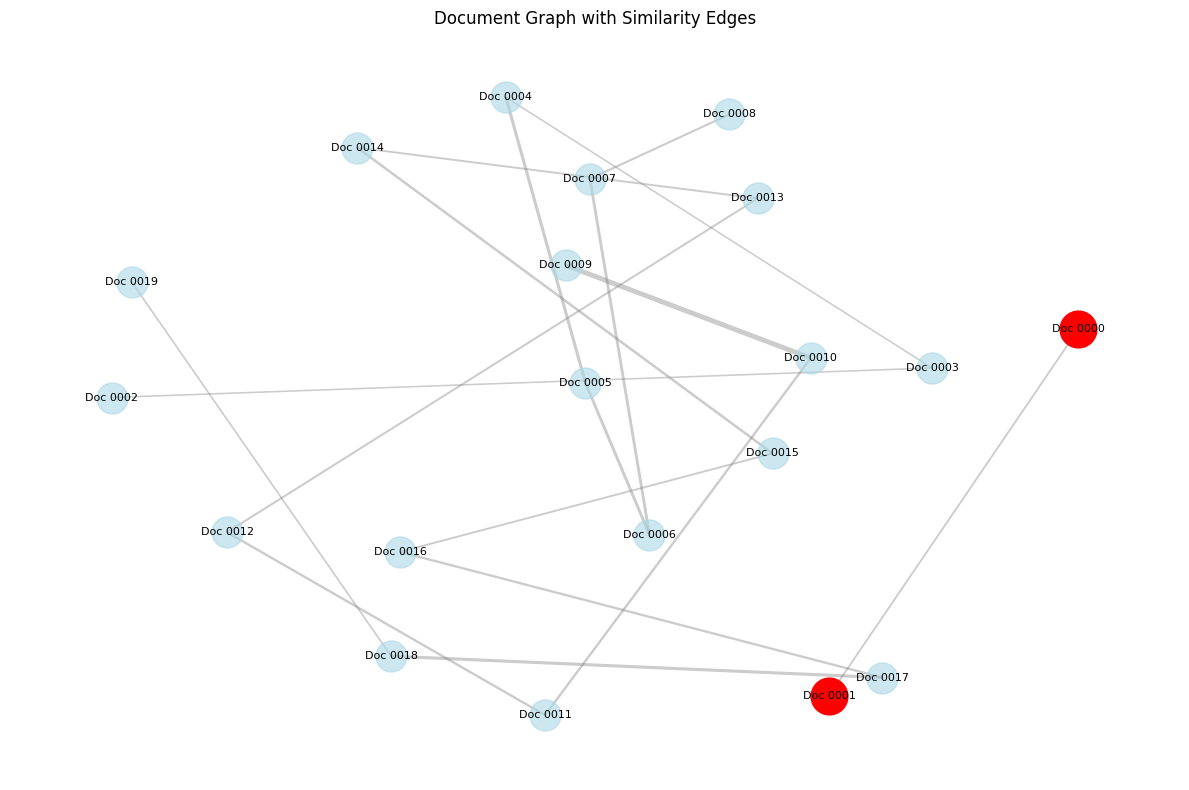

In [32]:
# Create pipeline
rag = SimpleRAGPipeline("https://en.wikipedia.org")

# Ingest data
rag.ingest(max_pages=2)

# Test queries
test_questions = [
    "How does machine learning relate to NLP?",
    "What are neural networks?",
    "Explain text processing"
]

for question in test_questions:
    print(f"\n\nQuery: {question}")

    print("\nTF-IDF Results:")
    tfidf_results = rag.query(question, search_type='tfidf', top_k=2)
    for i, result in enumerate(tfidf_results):
        print(f"  [{i+1}] {result[:200]}...")

    print("\nGraph BFS Results:")
    bfs_results = rag.query(question, search_type='bfs', top_k=2)
    for i, result in enumerate(bfs_results):
        print(f"  [{i+1}] {result[:200]}...")

# Visualize the graph
print("\nGenerating graph visualization...")
try:
    doc_graph.visualize(highlight_nodes=["doc_0000", "doc_0001"])
except Exception as e:
    print(f"Visualization skipped (display environment): {e}")